# Прогнозирование поздних осложнений COVID-19 по клиническим показателям

Классификация риска **постковидных (поздних) осложнений** на основе клинических
показателей острого периода заболевания.

## О ноутбуке

Этот ноутбук построен по образцу `covid_analysis_extended.ipynb`, но решает **другую задачу**:
вместо степени поражения лёгких (КТ) он предсказывает **поздние осложнения**, развившиеся
*после* лечения COVID-19.

В обновлённом наборе `updated_data.xlsx` (общая выборка — **755 пациентов**) начиная со столбца
**`DZ`** добавлены бинарные признаки поздних осложнений. Цель — оценить, можно ли по клиническим
показателям острого периода (демография, симптоматика, лабораторные данные, тяжесть КТ,
коморбидности) предсказать развитие осложнений.

### Задачи

1. **Главная цель — `Позд,ослож`** (любое позднее осложнение, ≈47 % пациентов): бинарная
   классификация четырьмя моделями (Decision Tree, Logistic Regression, Random Forest,
   Gradient Boosting) с подбором гиперпараметров.
2. **Отдельные осложнения** (с распространённостью ≥ 10 %): ССЗ, нарушения зрения/слуха,
   психо-неврологические, постковидная слабость, повторные пневмонии, патология ЖКТ/НЖБП —
   отдельные модели Random Forest и сводка предикторов.
3. **Важность признаков** — встроенная важность, permutation importance, консенсус и **SHAP**.
4. **Компактная прогностическая формула** риска любого осложнения (логистическая регрессия).

Анализ выполняется для четырёх когорт: **общая выборка** и три штамма (**Уханьский**, **Дельта**,
**Омикрон**).

> **Важно (отсутствие утечки данных).** В качестве признаков используются только показатели
> острого периода. Поздние лабораторные показатели (`EP..FI`) и сами столбцы осложнений
> в предикторы **не** включаются.

## 1. Импорт библиотек и загрузка данных

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

RANDOM_STATE = 42

In [2]:
FILE_PATH = 'updated_data.xlsx'
# Логические имена когорт -> реальные листы обновлённого файла
SHEET_MAP = {'ОБЩЕЕ': '0бщ.755', 'УХАНЬ': 'УХАНЬ', 'ДЕЛЬТА': 'ДЕЛЬТА', 'ОМИКРОН': 'ОМИКРОН'}
SHEET_NAMES = ['ОБЩЕЕ', 'УХАНЬ', 'ДЕЛЬТА', 'ОМИКРОН']

# --- Признаки (клинические показатели острого периода), как в covid_analysis_extended ---
# Демография, клиника, лаборатория, цитокины, коморбидности (42 признака) + тяжесть КТ.
FEATURE_COLS_IDX = [2, 3, 7, 10, 20, 29, 31, 32, 34, 35, 45, 48, 49, 50, 59, 61, 62, 63,
                    64, 69, 70, 71, 72, 73, 74, 75, 76, 77, 79, 82, 83, 84, 85, 86, 87,
                    97, 110, 111, 114, 116, 122, 123]
KT_IDX = 38                      # AM — КТ(ИТОГ): тяжесть поражения лёгких как клинический индикатор
PREDICTOR_IDX = FEATURE_COLS_IDX + [KT_IDX]

# --- Целевые переменные: поздние осложнения (бинарные флаги, начиная со столбца DZ=129) ---
PRIMARY_TARGET_IDX = 129         # DZ — Позд,ослож (любое позднее осложнение)
# Отдельные осложнения с достаточной распространённостью (>= ~10%):
SPECIFIC_TARGET_IDX = [130, 135, 136, 138, 140, 144]

# Загрузка
raw = {name: pd.read_excel(FILE_PATH, sheet_name=SHEET_MAP[name]) for name in SHEET_NAMES}

# Имена столбцов берём из файла
_cols = raw['ОБЩЕЕ'].columns
PREDICTOR_NAMES = [str(_cols[i]).strip() for i in PREDICTOR_IDX]
PRIMARY_NAME = str(_cols[PRIMARY_TARGET_IDX]).strip()
SPECIFIC_NAMES = [str(_cols[i]).strip() for i in SPECIFIC_TARGET_IDX]

def build_xy(df):
    X = df.iloc[:, PREDICTOR_IDX].apply(pd.to_numeric, errors='coerce')
    X.columns = PREDICTOR_NAMES
    y_primary = (pd.to_numeric(df.iloc[:, PRIMARY_TARGET_IDX], errors='coerce') > 0).astype(int)
    y_spec = df.iloc[:, SPECIFIC_TARGET_IDX].apply(pd.to_numeric, errors='coerce').gt(0).astype(int)
    y_spec.columns = SPECIFIC_NAMES
    return X, y_primary, y_spec

data = {name: build_xy(df) for name, df in raw.items()}

print(f'Признаков-предикторов: {len(PREDICTOR_NAMES)}')
print('Главная цель :', PRIMARY_NAME)
print('Отдельные цели:', SPECIFIC_NAMES)
print()
for name in SHEET_NAMES:
    X, yp, _ = data[name]
    print(f'{name:8s}: {X.shape[0]:4d} пациентов, осложнения у {int(yp.sum()):3d} ({100*yp.mean():.0f}%)')

Признаков-предикторов: 43
Главная цель : Позд,ослож
Отдельные цели: ['ССЗ/новые', 'Зрение, слух', 'Псих, ЦНС, обоняние', 'Пост,слабостб', 'Пневмонии/2 года', 'ЖКТ, НЖБП']

ОБЩЕЕ   :  755 пациентов, осложнения у 357 (47%)
УХАНЬ   :  213 пациентов, осложнения у  95 (45%)
ДЕЛЬТА  :  272 пациентов, осложнения у 138 (51%)
ОМИКРОН :  270 пациентов, осложнения у 124 (46%)


### 1.1 Список признаков-предикторов

In [3]:
print('Клинические показатели, используемые как предикторы:\n')
for i, (idx, nm) in enumerate(zip(PREDICTOR_IDX, PREDICTOR_NAMES), 1):
    print(f'  {i:>2d}. индекс {idx:>3d} -> {nm}')

Клинические показатели, используемые как предикторы:

   1. индекс   2 -> возраст
   2. индекс   3 -> пол
   3. индекс   7 -> день заболевания
   4. индекс  10 -> вакцинация
   5. индекс  20 -> темпер
   6. индекс  29 -> группа крови
   7. индекс  31 -> ИМТ
   8. индекс  32 -> ЧСС (пост)
   9. индекс  34 -> АД(сис)
  10. индекс  35 -> АД(диас)
  11. индекс  45 -> ЛЕЙКОЦ
  12. индекс  48 -> лимф
  13. индекс  49 -> моноц
  14. индекс  50 -> СОЭ
  15. индекс  59 -> АЛТ(пост)
  16. индекс  61 -> моч(пост)
  17. индекс  62 -> креат(пост
  18. индекс  63 -> Глюк(пост)
  19. индекс  64 -> АЛТ(ВЫП)
  20. индекс  69 -> ТГ
  21. индекс  70 -> холестерин
  22. индекс  71 -> Железо
  23. индекс  72 -> КК
  24. индекс  73 -> ЛДГ мах
  25. индекс  74 -> СРБ мах
  26. индекс  75 -> ферритин
  27. индекс  76 -> д-димер
  28. индекс  77 -> витД
  29. индекс  79 -> Фибриноген
  30. индекс  82 -> ССС заболевания
  31. индекс  83 -> Орг. Дых
  32. индекс  84 -> СД
  33. индекс  85 -> ЖКТ
  34. индекс  86

## 2. Предобработка данных

In [4]:
# Доля пропусков в признаках (общая выборка)
X_obs = data['ОБЩЕЕ'][0]
miss = (X_obs.isna().mean() * 100).sort_values(ascending=False)
print('Топ-15 признаков по доле пропусков (общая выборка), %:\n')
print(miss.head(15).round(1).to_string())
print(f'\nПризнаков без пропусков: {(miss == 0).sum()} из {len(miss)}')

Топ-15 признаков по доле пропусков (общая выборка), %:

д-димер             0.4
АД(диас)            0.1
АД(сис)             0.1
ЧСС (пост)          0.1
ИМТ                 0.1
ФНО                 0.1
день заболевания    0.0
группа крови        0.0
темпер              0.0
возраст             0.0
пол                 0.0
ЛЕЙКОЦ              0.0
вакцинация          0.0
СОЭ                 0.0
лимф                0.0

Признаков без пропусков: 37 из 43


## 3. Разведочный анализ (EDA)

### 3.1 Распространённость поздних осложнений по штаммам

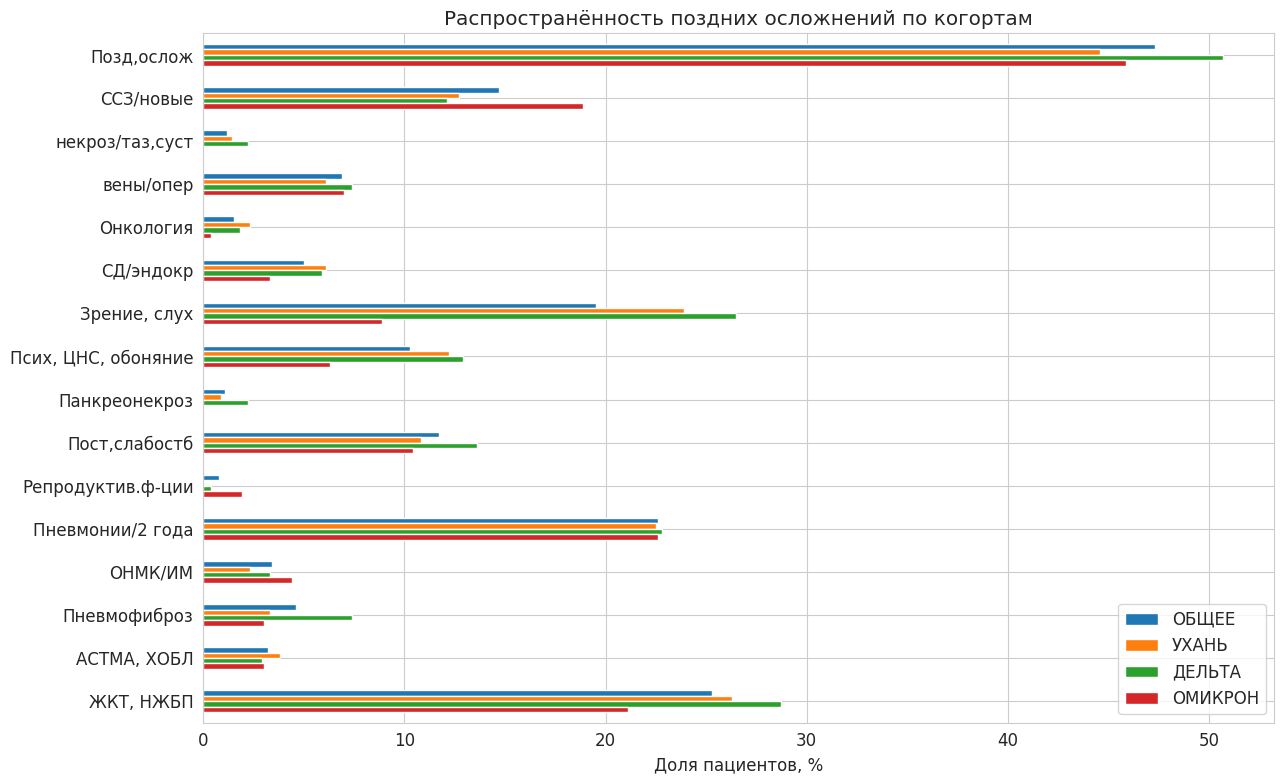

                     ОБЩЕЕ  УХАНЬ  ДЕЛЬТА  ОМИКРОН
Позд,ослож            47.3   44.6    50.7     45.9
ССЗ/новые             14.7   12.7    12.1     18.9
некроз/таз,суст        1.2    1.4     2.2      0.0
вены/опер              6.9    6.1     7.4      7.0
Онкология              1.5    2.3     1.8      0.4
СД/эндокр              5.0    6.1     5.9      3.3
Зрение, слух          19.5   23.9    26.5      8.9
Псих, ЦНС, обоняние   10.3   12.2    12.9      6.3
Панкреонекроз          1.1    0.9     2.2      0.0
Пост,слабостб         11.7   10.8    13.6     10.4
Репродуктив.ф-ции      0.8    0.0     0.4      1.9
Пневмонии/2 года      22.6   22.5    22.8     22.6
ОНМК/ИМ                3.4    2.3     3.3      4.4
Пневмофиброз           4.6    3.3     7.4      3.0
АСТМА, ХОБЛ            3.2    3.8     2.9      3.0
ЖКТ, НЖБП             25.3   26.3    28.7     21.1


In [5]:
# Все бинарные флаги осложнений DZ..EO (16 столбцов) для обзорной картины
COMP_IDX = list(range(129, 145))
COMP_NAMES = [str(raw['ОБЩЕЕ'].columns[i]).strip() for i in COMP_IDX]

prev = pd.DataFrame(index=COMP_NAMES)
for name in SHEET_NAMES:
    df = raw[name]
    flags = df.iloc[:, COMP_IDX].apply(pd.to_numeric, errors='coerce').gt(0)
    prev[name] = (flags.mean().values * 100)
prev = prev.round(1)

fig, ax = plt.subplots(figsize=(13, 8))
prev.plot.barh(ax=ax)
ax.set_xlabel('Доля пациентов, %')
ax.set_title('Распространённость поздних осложнений по когортам')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

print(prev.to_string())

### 3.2 Совстречаемость осложнений (корреляция флагов)

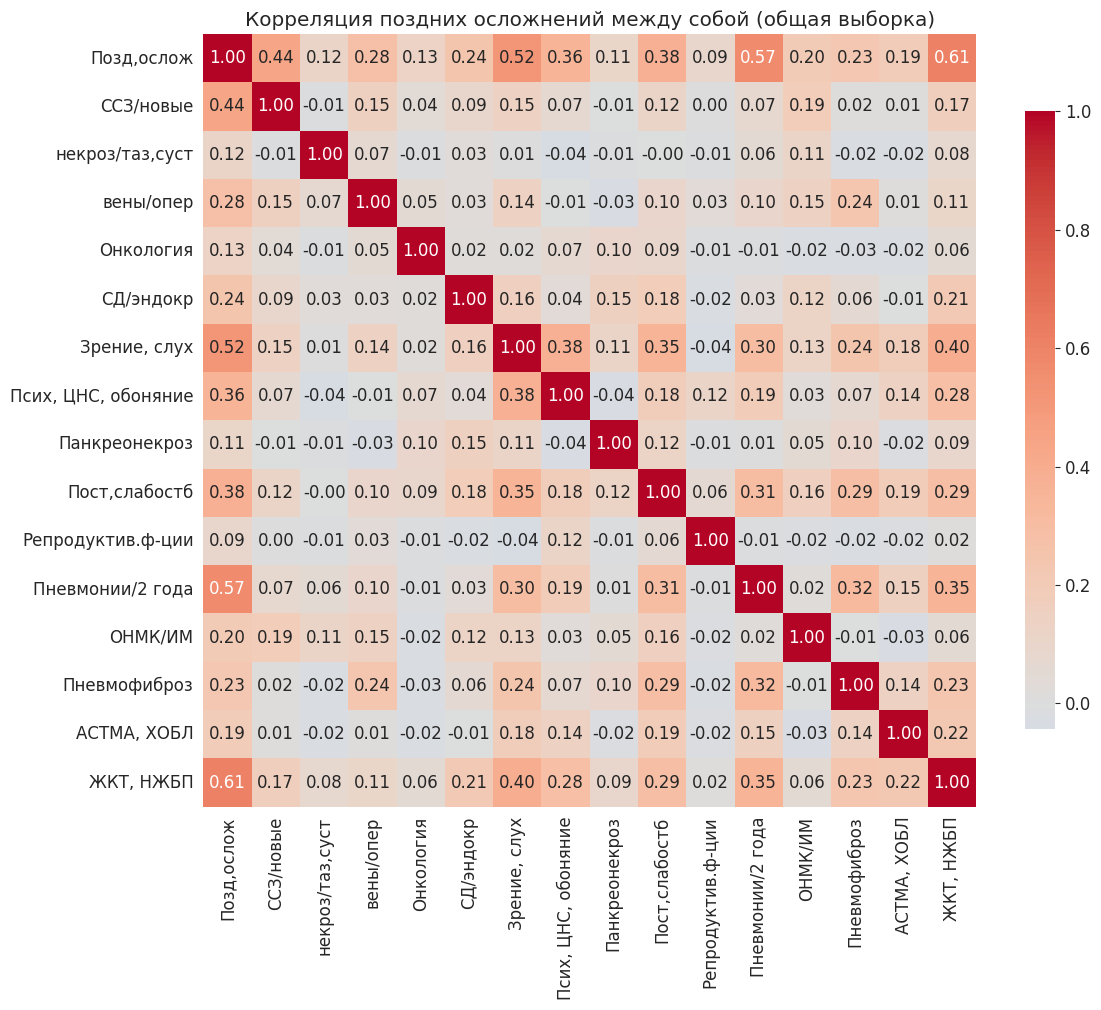

In [6]:
flags_all = raw['ОБЩЕЕ'].iloc[:, COMP_IDX].apply(pd.to_numeric, errors='coerce').gt(0).astype(int)
flags_all.columns = COMP_NAMES
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(flags_all.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink': .8}, ax=ax)
ax.set_title('Корреляция поздних осложнений между собой (общая выборка)')
plt.tight_layout(); plt.show()

### 3.3 Связь клинических показателей с любым осложнением

Для каждого признака — точечно-бисериальная корреляция с целевой переменной `Позд,ослож`
и сравнение средних у пациентов с осложнениями и без.

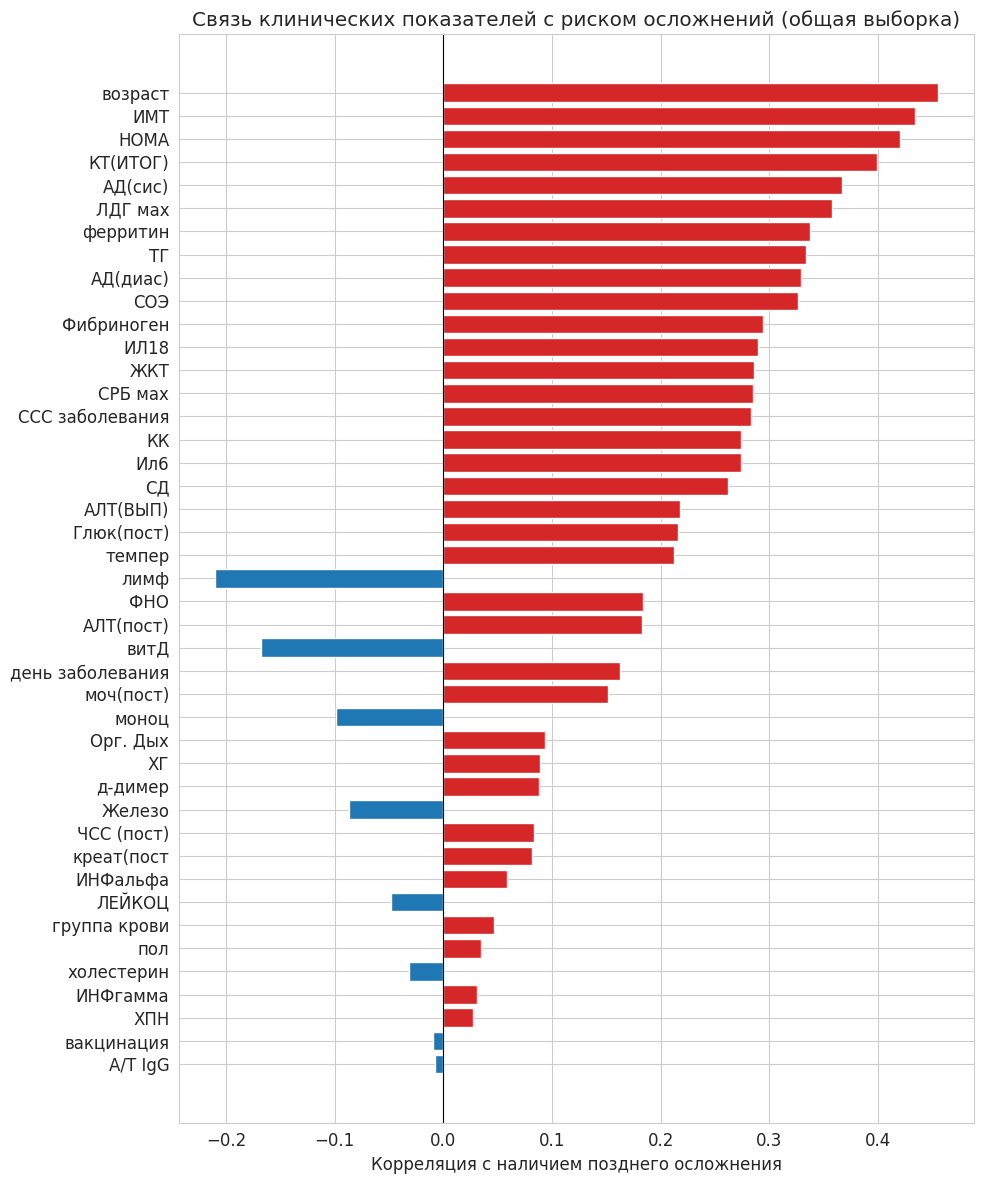

Топ-10 признаков по |корреляции| с осложнением:
возраст     0.455
ИМТ         0.434
HOMA        0.421
КТ(ИТОГ)    0.399
АД(сис)     0.367
ЛДГ мах     0.358
ферритин    0.337
ТГ          0.334
АД(диас)    0.329
СОЭ         0.326


In [7]:
X, yp, _ = data['ОБЩЕЕ']
Xf = X.fillna(X.median())
corr = Xf.corrwith(yp).sort_values(key=np.abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 12))
colors = ['#d62728' if v > 0 else '#1f77b4' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.invert_yaxis()
ax.axvline(0, color='k', lw=.8)
ax.set_xlabel('Корреляция с наличием позднего осложнения')
ax.set_title('Связь клинических показателей с риском осложнений (общая выборка)')
plt.tight_layout(); plt.show()

print('Топ-10 признаков по |корреляции| с осложнением:')
print(corr.head(10).round(3).to_string())

## 4. Подготовка данных к моделированию

In [8]:
# Train/test split по каждой когорте + импутация медианой (по train)
splits = {}
for name in SHEET_NAMES:
    X, yp, _ = data[name]
    X_train, X_test, y_train, y_test = train_test_split(
        X, yp, test_size=0.25, random_state=RANDOM_STATE, stratify=yp)
    med = X_train.median()
    X_train = X_train.fillna(med).fillna(0)
    X_test = X_test.fillna(med).fillna(0)
    splits[name] = (X_train, X_test, y_train, y_test)
    print(f'{name:8s}: train {X_train.shape[0]}, test {X_test.shape[0]}, '
          f'осложнений в test {int(y_test.sum())}/{len(y_test)}')

ОБЩЕЕ   : train 566, test 189, осложнений в test 89/189
УХАНЬ   : train 159, test 54, осложнений в test 24/54


ДЕЛЬТА  : train 204, test 68, осложнений в test 34/68
ОМИКРОН : train 202, test 68, осложнений в test 31/68


### 4.1 Вспомогательная функция оценки

In [9]:
def evaluate(model, name):
    X_train, X_test, y_train, y_test = splits[name]
    y_pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, proba),
    }

## 5. Decision Tree

In [10]:
dt_grid = {'max_depth': [3, 4, 5, 6], 'min_samples_leaf': [5, 10, 20]}
dt_models = {}
for name in SHEET_NAMES:
    X_train, X_test, y_train, y_test = splits[name]
    gs = GridSearchCV(DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
                      dt_grid, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                      scoring='roc_auc', n_jobs=-1)
    gs.fit(X_train, y_train)
    dt_models[name] = gs.best_estimator_
    print(f'{name:8s}: {gs.best_params_}  CV ROC-AUC={gs.best_score_:.3f}')

ОБЩЕЕ   : {'max_depth': 4, 'min_samples_leaf': 20}  CV ROC-AUC=0.789


УХАНЬ   : {'max_depth': 3, 'min_samples_leaf': 20}  CV ROC-AUC=0.785


ДЕЛЬТА  : {'max_depth': 3, 'min_samples_leaf': 10}  CV ROC-AUC=0.692


ОМИКРОН : {'max_depth': 3, 'min_samples_leaf': 20}  CV ROC-AUC=0.796


## 6. Logistic Regression

In [11]:
lr_grid = {'clf__C': [0.05, 0.1, 0.5, 1, 5, 10]}
lr_models = {}
for name in SHEET_NAMES:
    X_train, X_test, y_train, y_test = splits[name]
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('clf', LogisticRegression(class_weight='balanced', max_iter=5000,
                                                random_state=RANDOM_STATE))])
    gs = GridSearchCV(pipe, lr_grid, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                      scoring='roc_auc', n_jobs=-1)
    gs.fit(X_train, y_train)
    lr_models[name] = gs.best_estimator_
    print(f'{name:8s}: C={gs.best_params_["clf__C"]}  CV ROC-AUC={gs.best_score_:.3f}')

ОБЩЕЕ   : C=0.05  CV ROC-AUC=0.839


УХАНЬ   : C=0.05  CV ROC-AUC=0.856


ДЕЛЬТА  : C=0.05  CV ROC-AUC=0.795


ОМИКРОН : C=0.05  CV ROC-AUC=0.762


## 7. Random Forest

In [12]:
rf_grid = {'n_estimators': [200, 300], 'max_depth': [5, 7, 10], 'min_samples_leaf': [2, 5]}
rf_models = {}
for name in SHEET_NAMES:
    X_train, X_test, y_train, y_test = splits[name]
    gs = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
                      rf_grid, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                      scoring='roc_auc', n_jobs=-1)
    gs.fit(X_train, y_train)
    rf_models[name] = gs.best_estimator_
    print(f'{name:8s}: {gs.best_params_}  CV ROC-AUC={gs.best_score_:.3f}')

ОБЩЕЕ   : {'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 200}  CV ROC-AUC=0.835


УХАНЬ   : {'max_depth': 7, 'min_samples_leaf': 5, 'n_estimators': 200}  CV ROC-AUC=0.856


ДЕЛЬТА  : {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 200}  CV ROC-AUC=0.818


ОМИКРОН : {'max_depth': 5, 'min_samples_leaf': 2, 'n_estimators': 200}  CV ROC-AUC=0.806


## 8. Gradient Boosting

In [13]:
gb_grid = {'n_estimators': [100, 200], 'max_depth': [2, 3], 'learning_rate': [0.05, 0.1]}
gb_models = {}
for name in SHEET_NAMES:
    X_train, X_test, y_train, y_test = splits[name]
    sw = compute_sample_weight('balanced', y_train)
    gs = GridSearchCV(GradientBoostingClassifier(random_state=RANDOM_STATE),
                      gb_grid, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                      scoring='roc_auc', n_jobs=-1)
    gs.fit(X_train, y_train, sample_weight=sw)
    gb_models[name] = gs.best_estimator_
    print(f'{name:8s}: {gs.best_params_}  CV ROC-AUC={gs.best_score_:.3f}')

ОБЩЕЕ   : {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200}  CV ROC-AUC=0.834


УХАНЬ   : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}  CV ROC-AUC=0.840


ДЕЛЬТА  : {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100}  CV ROC-AUC=0.769


ОМИКРОН : {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100}  CV ROC-AUC=0.798


## 9. Сравнение моделей

In [14]:
model_dicts = {'Decision Tree': dt_models, 'Logistic Regression': lr_models,
               'Random Forest': rf_models, 'Gradient Boosting': gb_models}
rows = []
for mname, md_ in model_dicts.items():
    for sheet in SHEET_NAMES:
        m = evaluate(md_[sheet], sheet)
        rows.append({'Модель': mname, 'Когорта': sheet, **{k: round(v, 3) for k, v in m.items()}})
results = pd.DataFrame(rows)
pivot_auc = results.pivot(index='Модель', columns='Когорта', values='ROC-AUC')[SHEET_NAMES]
print('ROC-AUC по моделям и когортам (test):\n')
print(pivot_auc.to_string())
print('\nF1 по моделям и когортам (test):\n')
print(results.pivot(index='Модель', columns='Когорта', values='F1')[SHEET_NAMES].to_string())

ROC-AUC по моделям и когортам (test):

Когорта              ОБЩЕЕ  УХАНЬ  ДЕЛЬТА  ОМИКРОН
Модель                                            
Decision Tree        0.788  0.688   0.795    0.762
Gradient Boosting    0.757  0.754   0.858    0.818
Logistic Regression  0.761  0.782   0.847    0.799
Random Forest        0.791  0.751   0.860    0.823

F1 по моделям и когортам (test):

Когорта              ОБЩЕЕ  УХАНЬ  ДЕЛЬТА  ОМИКРОН
Модель                                            
Decision Tree        0.698  0.667   0.700    0.667
Gradient Boosting    0.667  0.652   0.771    0.762
Logistic Regression  0.694  0.652   0.746    0.700
Random Forest        0.715  0.622   0.761    0.781


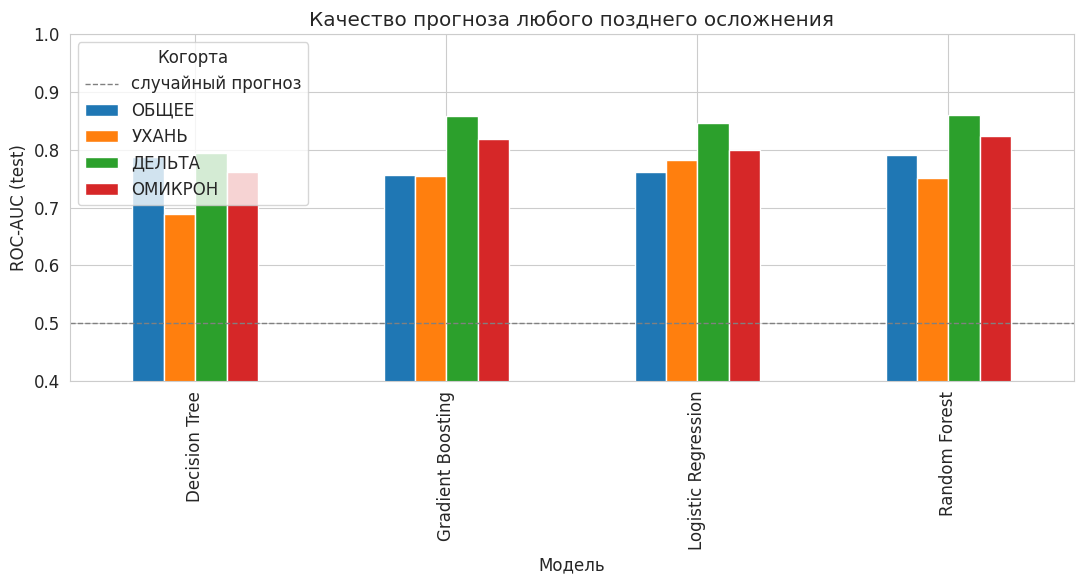

In [15]:
fig, ax = plt.subplots(figsize=(11, 6))
pivot_auc.plot.bar(ax=ax)
ax.set_ylabel('ROC-AUC (test)')
ax.set_title('Качество прогноза любого позднего осложнения')
ax.axhline(0.5, color='grey', ls='--', lw=1, label='случайный прогноз')
ax.set_ylim(0.4, 1.0); ax.legend(title='Когорта')
plt.tight_layout(); plt.show()

### 9.1 Матрицы ошибок и ROC-кривые (лучшая модель)

В качестве рабочей модели берём **Random Forest** (устойчивая важность признаков и SHAP).

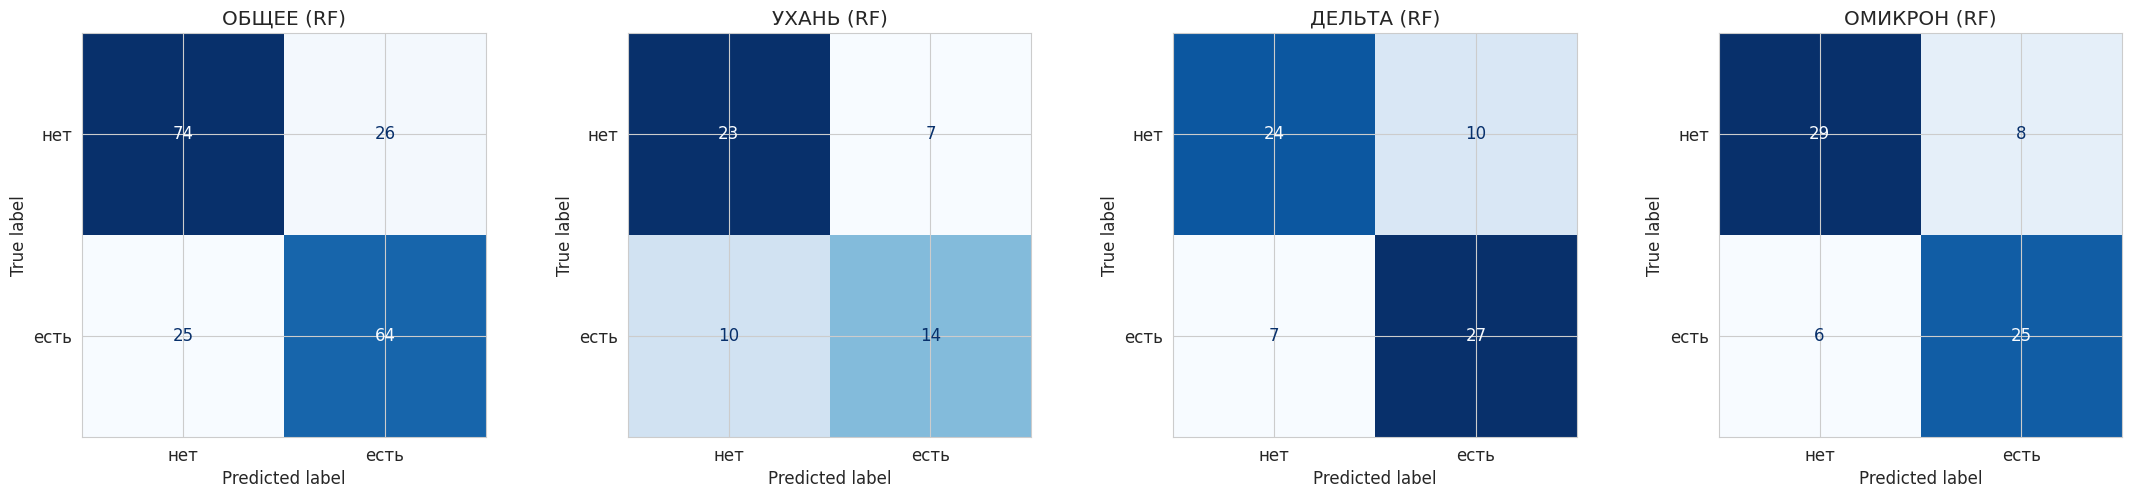

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, name in zip(axes, SHEET_NAMES):
    X_train, X_test, y_train, y_test = splits[name]
    y_pred = rf_models[name].predict(X_test)
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                           display_labels=['нет', 'есть']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name} (RF)')
plt.tight_layout(); plt.show()

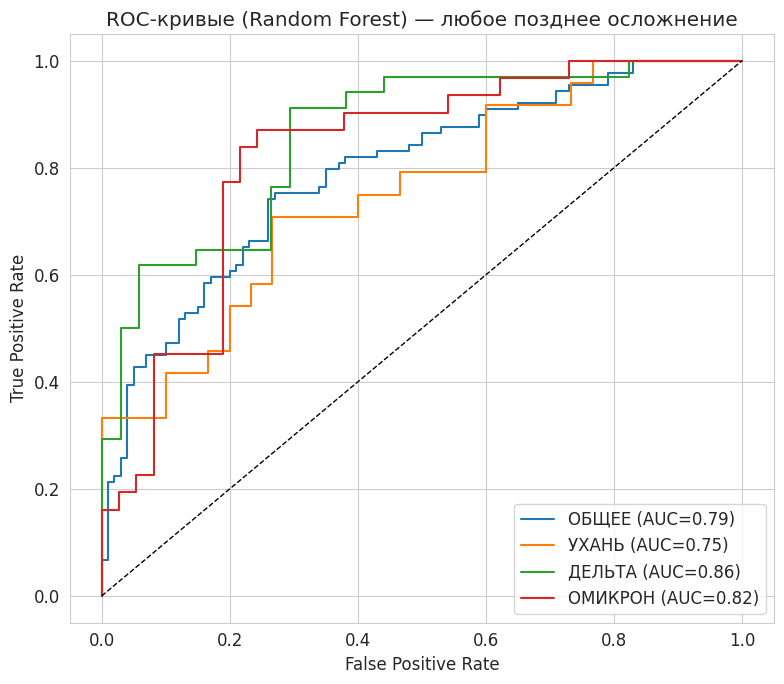

In [17]:
fig, ax = plt.subplots(figsize=(8, 7))
for name in SHEET_NAMES:
    X_train, X_test, y_train, y_test = splits[name]
    proba = rf_models[name].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, proba):.2f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-кривые (Random Forest) — любое позднее осложнение')
ax.legend(); plt.tight_layout(); plt.show()

## 10. Важность признаков

### 10.1 Встроенная важность (Random Forest)

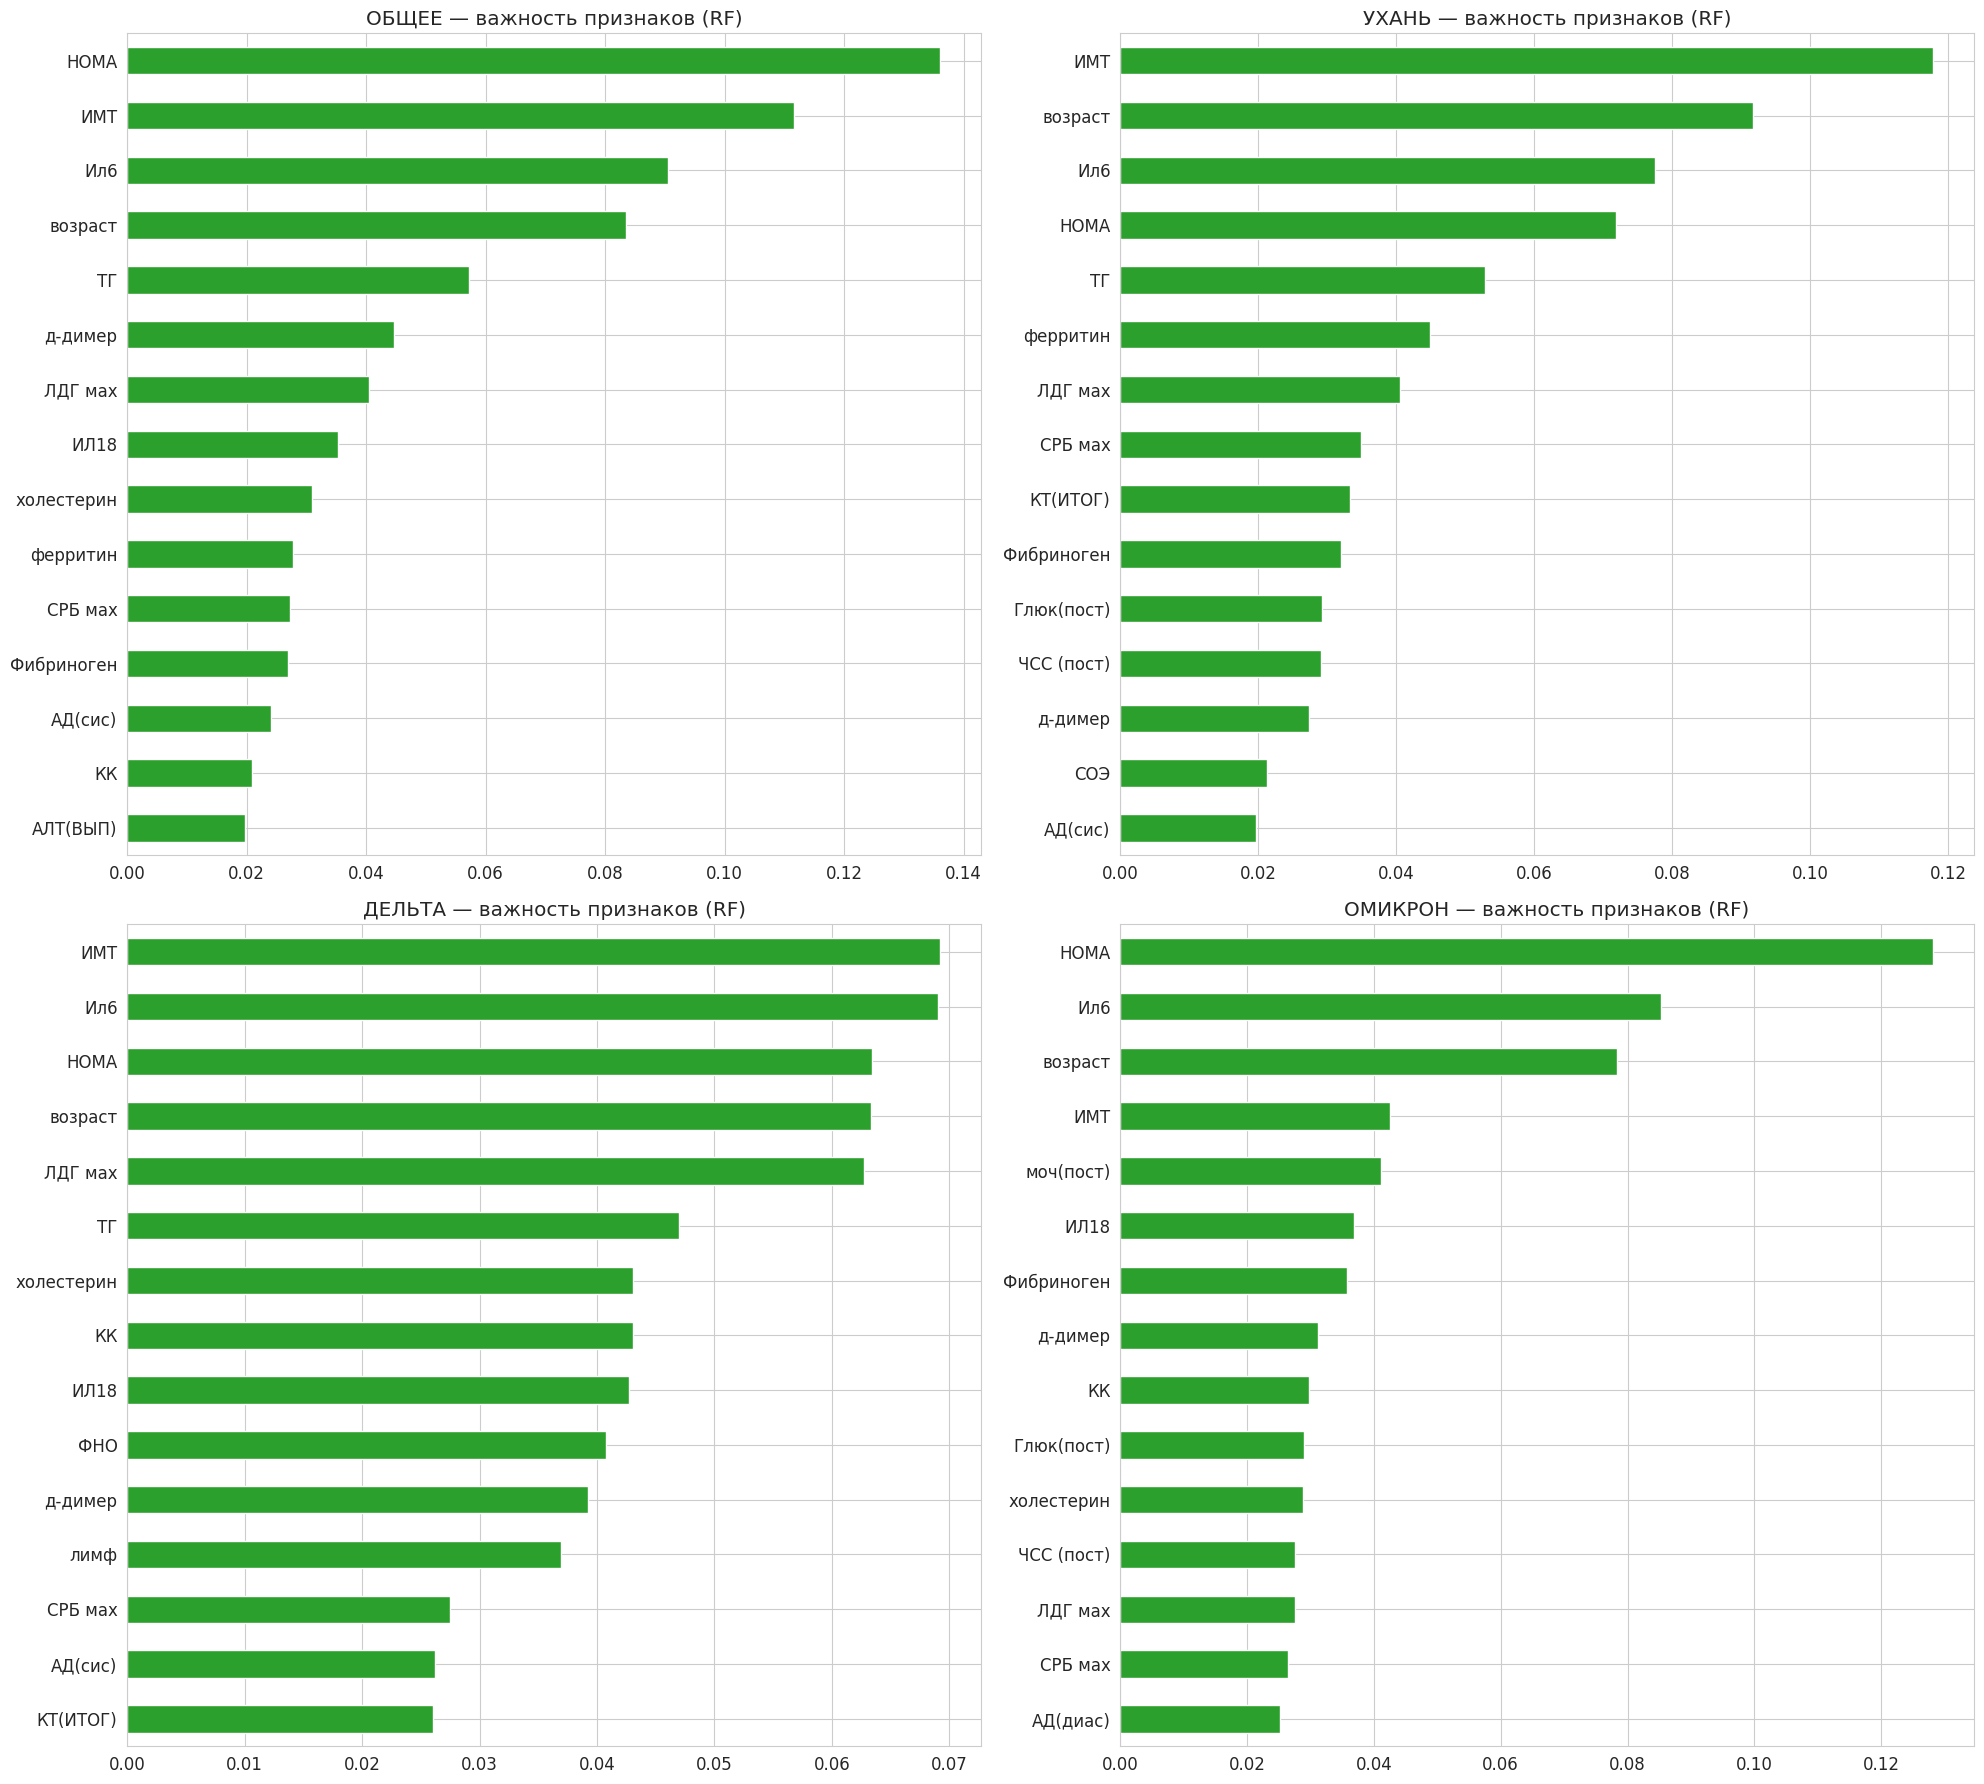

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(20, 18))
for ax, name in zip(axes.flatten(), SHEET_NAMES):
    imp = pd.Series(rf_models[name].feature_importances_, index=PREDICTOR_NAMES)
    imp.sort_values().tail(15).plot.barh(ax=ax, color='#2ca02c')
    ax.set_title(f'{name} — важность признаков (RF)')
plt.tight_layout(); plt.show()

### 10.2 Permutation importance и консенсус

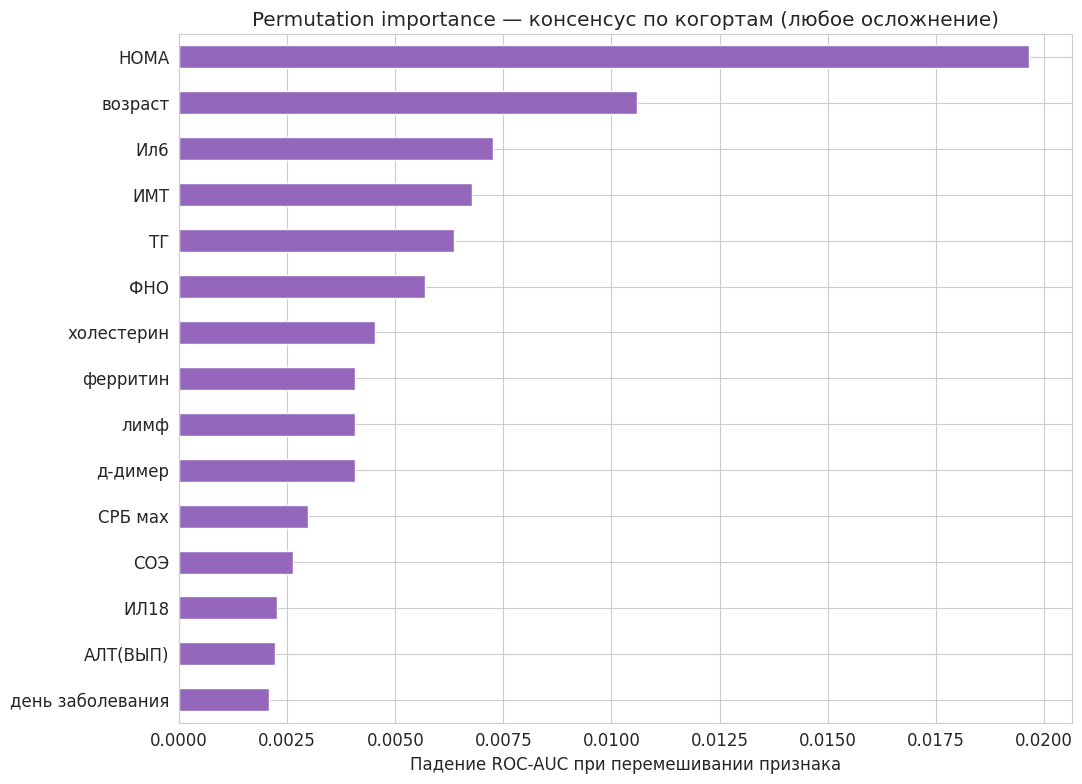

                   ОБЩЕЕ   УХАНЬ  ДЕЛЬТА  ОМИКРОН  Консенсус
HOMA              0.0264  0.0157  0.0247   0.0118     0.0197
возраст           0.0137 -0.0032  0.0161   0.0158     0.0106
Ил6               0.0105 -0.0001  0.0057   0.0129     0.0073
ИМТ               0.0074  0.0073  0.0062   0.0062     0.0068
ТГ                0.0038  0.0056  0.0139   0.0021     0.0063
ФНО               0.0024  0.0027  0.0070   0.0107     0.0057
холестерин        0.0027 -0.0006  0.0040   0.0120     0.0045
ферритин          0.0014  0.0100  0.0033   0.0016     0.0041
лимф              0.0010  0.0053  0.0076   0.0024     0.0041
д-димер           0.0081 -0.0018  0.0048   0.0051     0.0041
СРБ мах           0.0019 -0.0002  0.0055   0.0046     0.0030
СОЭ               0.0004  0.0015  0.0017   0.0070     0.0026
ИЛ18             -0.0004  0.0019  0.0062   0.0013     0.0023
АЛТ(ВЫП)         -0.0011  0.0022  0.0058   0.0020     0.0022
день заболевания  0.0003  0.0044  0.0060  -0.0024     0.0021


In [19]:
perm = pd.DataFrame(index=PREDICTOR_NAMES)
for name in SHEET_NAMES:
    X_train, X_test, y_train, y_test = splits[name]
    r = permutation_importance(rf_models[name], X_test, y_test, n_repeats=15,
                               random_state=RANDOM_STATE, scoring='roc_auc', n_jobs=-1)
    perm[name] = r.importances_mean
perm['Консенсус'] = perm[SHEET_NAMES].mean(axis=1)
top = perm.sort_values('Консенсус', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 8))
top['Консенсус'].iloc[::-1].plot.barh(ax=ax, color='#9467bd')
ax.set_xlabel('Падение ROC-AUC при перемешивании признака')
ax.set_title('Permutation importance — консенсус по когортам (любое осложнение)')
plt.tight_layout(); plt.show()
print(perm.sort_values('Консенсус', ascending=False).head(15).round(4).to_string())

### 10.3 SHAP — глобальные и индивидуальные объяснения

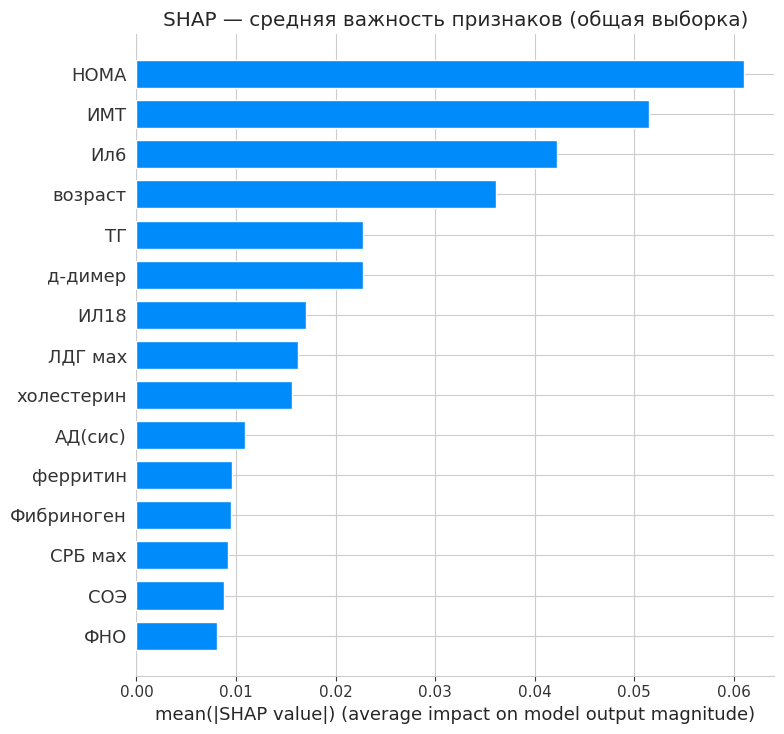

In [20]:
import shap

name = 'ОБЩЕЕ'
X_train, X_test, y_train, y_test = splits[name]
explainer = shap.TreeExplainer(rf_models[name])
sv = explainer.shap_values(X_test)
# Для бинарного RF берём вклад в класс 1 (есть осложнение)
sv1 = sv[1] if isinstance(sv, list) else (sv[..., 1] if sv.ndim == 3 else sv)

shap.summary_plot(sv1, X_test, plot_type='bar', show=False, max_display=15)
plt.title('SHAP — средняя важность признаков (общая выборка)')
plt.tight_layout(); plt.show()

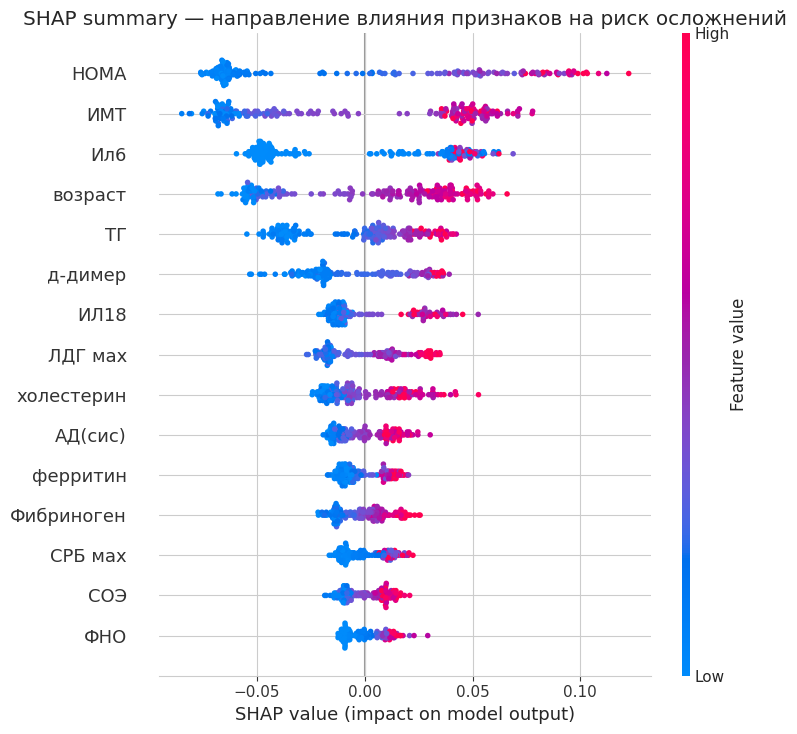

In [21]:
shap.summary_plot(sv1, X_test, show=False, max_display=15)
plt.title('SHAP summary — направление влияния признаков на риск осложнений')
plt.tight_layout(); plt.show()

## 11. Прогноз отдельных осложнений

Для каждого распространённого осложнения (≥ ~10 %) обучаем Random Forest на общей выборке и
оцениваем качество (ROC-AUC) на отложенной выборке.

In [22]:
spec_rows = []
spec_models = {}
spec_import = pd.DataFrame(index=PREDICTOR_NAMES)
X_all, _, y_spec_all = data['ОБЩЕЕ']
X_all_f = X_all.fillna(X_all.median()).fillna(0)

for comp in SPECIFIC_NAMES:
    y = y_spec_all[comp]
    Xtr, Xte, ytr, yte = train_test_split(X_all_f, y, test_size=0.25,
                                          random_state=RANDOM_STATE, stratify=y)
    m = RandomForestClassifier(n_estimators=300, max_depth=7, min_samples_leaf=3,
                               class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(Xtr, ytr)
    proba = m.predict_proba(Xte)[:, 1]
    spec_models[comp] = m
    spec_import[comp] = m.feature_importances_
    spec_rows.append({'Осложнение': comp, 'Распростр., %': round(100 * y.mean(), 1),
                      'ROC-AUC': round(roc_auc_score(yte, proba), 3),
                      'F1': round(f1_score(yte, m.predict(Xte)), 3)})

spec_summary = pd.DataFrame(spec_rows).sort_values('ROC-AUC', ascending=False)
print(spec_summary.to_string(index=False))

         Осложнение  Распростр., %  ROC-AUC    F1
       Зрение, слух           19.5    0.827 0.507
          ЖКТ, НЖБП           25.3    0.820 0.571
          ССЗ/новые           14.7    0.804 0.390
Псих, ЦНС, обоняние           10.3    0.695 0.174
      Пост,слабостб           11.7    0.683 0.324
   Пневмонии/2 года           22.6    0.620 0.293


### 11.1 Главные предикторы каждого осложнения

Ведущие клинические предикторы по каждому осложнению (RF importance):

  ССЗ/новые     : возраст (0.08), ССС заболевания (0.06), ИМТ (0.06)
  Зрение, слух  : возраст (0.08), ФНО (0.06), ЛДГ мах (0.05)
  Псих, ЦНС, обоняние: возраст (0.06), ЛЕЙКОЦ (0.05), Железо (0.05)
  Пост,слабостб : HOMA (0.07), ИМТ (0.07), ферритин (0.06)
  Пневмонии/2 года: HOMA (0.07), ИМТ (0.06), возраст (0.04)
  ЖКТ, НЖБП     : ИМТ (0.13), ТГ (0.09), HOMA (0.09)


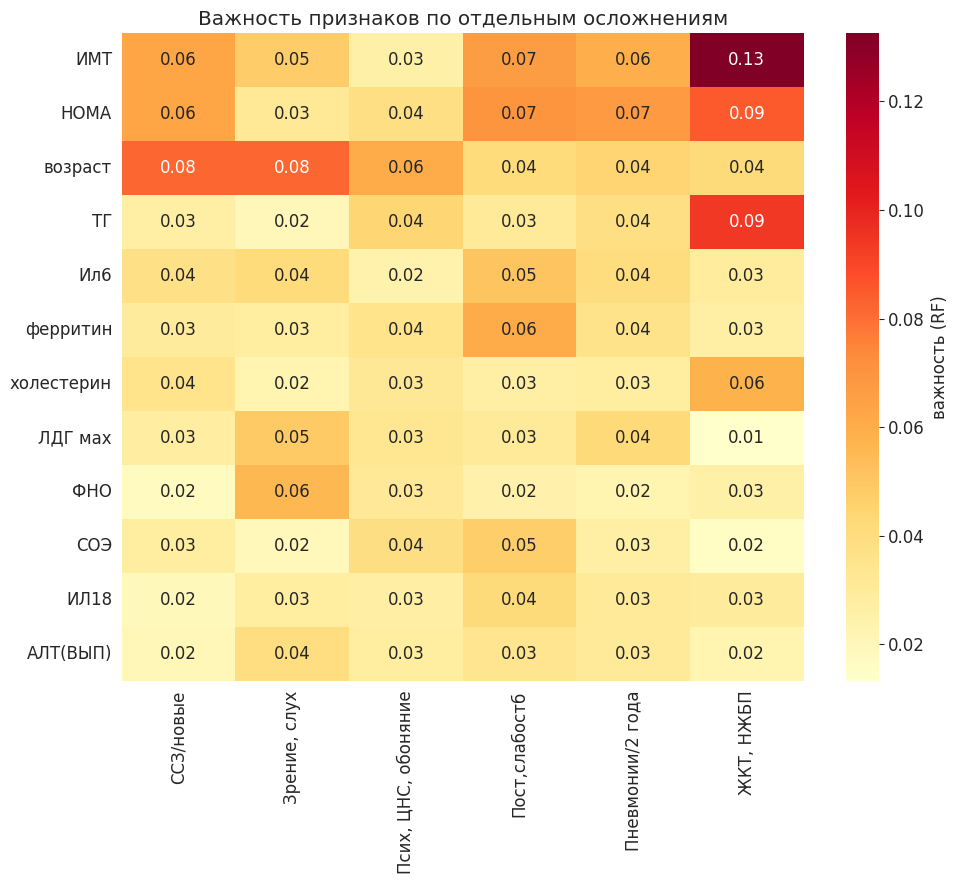

In [23]:
# Топ-предиктор и топ-3 по важности для каждого осложнения
print('Ведущие клинические предикторы по каждому осложнению (RF importance):\n')
for comp in SPECIFIC_NAMES:
    top3 = spec_import[comp].sort_values(ascending=False).head(3)
    items = ', '.join(f'{k} ({v:.2f})' for k, v in top3.items())
    print(f'  {comp:14s}: {items}')

# Теплокарта важности: признаки x осложнения (топ-12 признаков по суммарной важности)
top_feats = spec_import.sum(axis=1).sort_values(ascending=False).head(12).index
fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(spec_import.loc[top_feats], annot=True, fmt='.2f', cmap='YlOrRd',
            cbar_kws={'label': 'важность (RF)'}, ax=ax)
ax.set_title('Важность признаков по отдельным осложнениям')
plt.tight_layout(); plt.show()

## 12. Компактная прогностическая формула риска осложнений

Логистическая регрессия на стандартизованных признаках общей выборки даёт прозрачную
аддитивную модель: риск выражается через сумму вкладов признаков (лог-шансы) и сигмоиду.

Полная логистическая модель: ROC-AUC (test) = 0.741



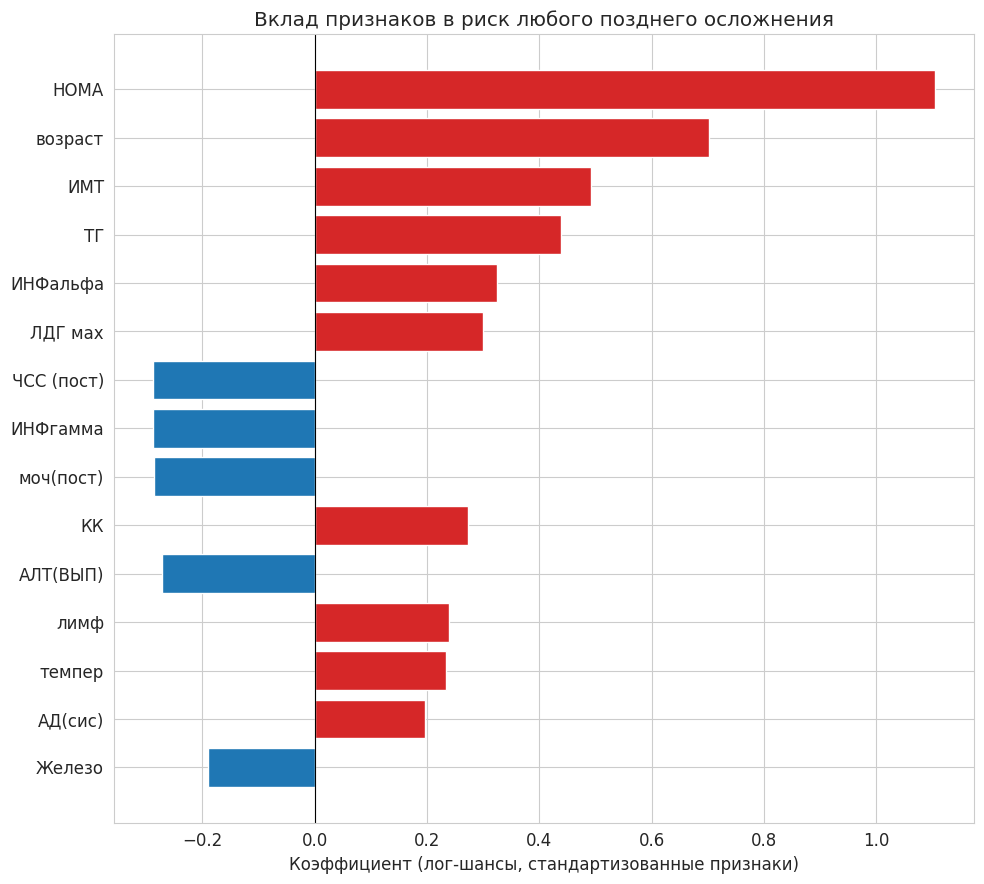

In [24]:
X_train, X_test, y_train, y_test = splits['ОБЩЕЕ']
scaler = StandardScaler().fit(X_train)
lr = LogisticRegression(class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE)
lr.fit(scaler.transform(X_train), y_train)

coef = pd.Series(lr.coef_[0], index=PREDICTOR_NAMES).sort_values(key=np.abs, ascending=False)
auc = roc_auc_score(y_test, lr.predict_proba(scaler.transform(X_test))[:, 1])
print(f'Полная логистическая модель: ROC-AUC (test) = {auc:.3f}\n')

fig, ax = plt.subplots(figsize=(10, 9))
top = coef.head(15).iloc[::-1]
ax.barh(top.index, top.values, color=['#d62728' if v > 0 else '#1f77b4' for v in top.values])
ax.axvline(0, color='k', lw=.8)
ax.set_xlabel('Коэффициент (лог-шансы, стандартизованные признаки)')
ax.set_title('Вклад признаков в риск любого позднего осложнения')
plt.tight_layout(); plt.show()

### 12.1 Упрощённая формула — топ-8 признаков

In [25]:
top8 = coef.head(8).index.tolist()
i8 = [PREDICTOR_NAMES.index(f) for f in top8]
sc8 = StandardScaler().fit(X_train[top8])
lr8 = LogisticRegression(class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE)
lr8.fit(sc8.transform(X_train[top8]), y_train)
auc8 = roc_auc_score(y_test, lr8.predict_proba(sc8.transform(X_test[top8]))[:, 1])

print(f'Упрощённая модель (8 признаков): ROC-AUC (test) = {auc8:.3f}')
print(f'(полная модель из {len(PREDICTOR_NAMES)} признаков: {auc:.3f})\n')

print('Риск = sigmoid(z),  z = %.3f' % lr8.intercept_[0])
for f, w, mu, sd in zip(top8, lr8.coef_[0], sc8.mean_, sc8.scale_):
    print(f'        {w:+.3f} * ( {f} - {mu:.2f} ) / {sd:.2f}')
print('\nsigmoid(z) = 1 / (1 + exp(-z));  риск > 0.5  ->  высокий риск осложнений')

Упрощённая модель (8 признаков): ROC-AUC (test) = 0.786
(полная модель из 43 признаков: 0.741)

Риск = sigmoid(z),  z = 0.081
        +0.953 * ( HOMA - 2.03 ) / 1.84
        +0.629 * ( возраст - 37.82 ) / 13.09
        +0.383 * ( ИМТ - 27.17 ) / 3.86
        +0.297 * ( ТГ - 1.62 ) / 1.14
        +0.288 * ( ИНФальфа - 1.97 ) / 3.60
        +0.382 * ( ЛДГ мах - 338.39 ) / 153.40
        -0.232 * ( ЧСС (пост) - 91.00 ) / 45.85
        -0.127 * ( ИНФгамма - 0.78 ) / 2.97

sigmoid(z) = 1 / (1 + exp(-z));  риск > 0.5  ->  высокий риск осложнений


## 13. Выводы

In [26]:
print('=' * 72)
print('  ИТОГОВЫЕ ВЫВОДЫ — прогноз поздних осложнений COVID-19')
print('=' * 72)

best = results.loc[results.groupby('Когорта')['ROC-AUC'].idxmax()]
print('\n1. Любое позднее осложнение — лучшая модель по когортам (ROC-AUC):')
for _, r in best.iterrows():
    print(f'   {r["Когорта"]:8s}: {r["Модель"]:18s} ROC-AUC={r["ROC-AUC"]:.3f}')

print('\n2. Ведущие клинические предикторы (permutation importance, консенсус):')
for f, v in perm['Консенсус'].sort_values(ascending=False).head(8).items():
    print(f'   {f:18s}  {v:.4f}')

print('\n3. Отдельные осложнения — качество прогноза (ROC-AUC):')
for _, r in spec_summary.iterrows():
    print(f'   {r["Осложнение"]:14s}: AUC={r["ROC-AUC"]:.3f}  (распростр. {r["Распростр., %"]}%)')

print(f'\n4. Компактная формула из 8 признаков сохраняет качество: '
      f'ROC-AUC={auc8:.3f} против {auc:.3f} у полной модели.')
print('\nПримечание: использованы только показатели острого периода; утечка данных исключена.')

  ИТОГОВЫЕ ВЫВОДЫ — прогноз поздних осложнений COVID-19

1. Любое позднее осложнение — лучшая модель по когортам (ROC-AUC):
   ДЕЛЬТА  : Random Forest      ROC-AUC=0.860
   ОБЩЕЕ   : Random Forest      ROC-AUC=0.791
   ОМИКРОН : Random Forest      ROC-AUC=0.823
   УХАНЬ   : Logistic Regression ROC-AUC=0.782

2. Ведущие клинические предикторы (permutation importance, консенсус):
   HOMA                0.0197
   возраст             0.0106
   Ил6                 0.0073
   ИМТ                 0.0068
   ТГ                  0.0063
   ФНО                 0.0057
   холестерин          0.0045
   ферритин            0.0041

3. Отдельные осложнения — качество прогноза (ROC-AUC):
   Зрение, слух  : AUC=0.827  (распростр. 19.5%)
   ЖКТ, НЖБП     : AUC=0.820  (распростр. 25.3%)
   ССЗ/новые     : AUC=0.804  (распростр. 14.7%)
   Псих, ЦНС, обоняние: AUC=0.695  (распростр. 10.3%)
   Пост,слабостб : AUC=0.683  (распростр. 11.7%)
   Пневмонии/2 года: AUC=0.620  (распростр. 22.6%)

4. Компактная формула